In [ ]:
!sudo apt-get install -y fonts-noto-cjk
!rm -rf ~/.cache/matplotlib

print("Đã cài đặt font và xóa bộ đệm font. Vui lòng KHỞI ĐỘNG LẠI THỜI GIAN CHẠY (Runtime -> Restart runtime) ngay bây giờ, sau đó chạy ô tiếp theo để áp dụng cài đặt font.")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-noto-cjk is already the newest version (1:20220127+repack1-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
Đã cài đặt font và xóa bộ đệm font. Vui lòng KHỞI ĐỘNG LẠI THỜI GIAN CHẠY (Runtime -> Restart runtime) ngay bây giờ, sau đó chạy ô tiếp theo để áp dụng cài đặt font.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Đặt kiểu hiển thị gọn gàng và hiện đại cho tất cả biểu đồ
plt.style.use('seaborn-v0_8-darkgrid')

# Cấu hình Matplotlib sử dụng font hỗ trợ ký tự tiếng Việt
plt.rcParams['font.family'] = 'sans-serif' # Sử dụng họ font sans-serif chung
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'DejaVu Sans', 'Arial', 'Liberation Sans'] # Ưu tiên Noto Sans CJK JP

In [ ]:
from google.colab import drive
drive.mount('/content/ggdrive')

Mounted at /content/ggdrive


In [ ]:
import pandas as pd
data = pd.read_csv(
    '/content/ggdrive/MyDrive/python project/sleep_health_lifestyle_dataset.csv'
    )
data


,Person ID,Gender,Age,Occupation,Sleep Duration (hours),Quality of Sleep (scale: 1-10),Physical Activity Level (minutes/day),Stress Level (scale: 1-10),BMI Category,Blood Pressure (systolic/diastolic),Heart Rate (bpm),Daily Steps,Sleep Disorder
0,1,Male,29,Manual Labor,7.4,7.0,41,7,Obese,124/70,91,8539,NaN
1,2,Female,43,Retired,4.2,4.9,41,5,Obese,131/86,81,18754,NaN
2,3,Male,44,Retired,6.1,6.0,107,4,Underweight,122/70,81,2857,NaN
3,4,Male,29,Office Worker,8.3,10.0,20,10,Obese,124/72,55,6886,NaN
4,5,Male,67,Retired,9.1,9.5,19,4,Overweight,133/78,97,14945,Insomnia
...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,396,Female,36,Student,4.5,7.9,73,7,Normal,118/66,64,14497,Sleep Apnea
396,397,Female,45,Manual Labor,6.0,6.1,72,8,Obese,132/80,65,12848,Insomnia
397,398,Female,30,Student,5.3,6.5,58,10,Obese,125/76,66,15255,Insomnia
398,399,Female,41,Retired,11.0,9.1,73,9,Obese,130/75,75,6567,Sleep Apnea


**Giới thiệu đề tài:**

Mục tiêu của project là kiểm định xem thời lượng ngủ trung bình giữa nam và nữ có khác nhau hay không. Đồng thời phân tích mối quan hệ giữa mức độ căng thẳng và thời lượng ngủ bằng các phương pháp thống kê.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 13 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Person ID                              400 non-null    int64  
 1   Gender                                 400 non-null    object 
 2   Age                                    400 non-null    int64  
 3   Occupation                             400 non-null    object 
 4   Sleep Duration (hours)                 400 non-null    float64
 5   Quality of Sleep (scale: 1-10)         400 non-null    float64
 6   Physical Activity Level (minutes/day)  400 non-null    int64  
 7   Stress Level (scale: 1-10)             400 non-null    int64  
 8   BMI Category                           400 non-null    object 
 9   Blood Pressure (systolic/diastolic)    400 non-null    object 
 10  Heart Rate (bpm)                       400 non-null    int64  
 11  Daily 

In [ ]:
data.describe()

,Person ID,Age,Sleep Duration (hours),Quality of Sleep (scale: 1-10),Physical Activity Level (minutes/day),Stress Level (scale: 1-10),Heart Rate (bpm),Daily Steps
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.00000,400.000000,400.000000
mean,200.500000,39.950000,8.041250,6.125750,64.985000,5.47250,75.990000,11076.510000
std,115.614301,14.038883,2.390787,1.975733,32.297874,2.80873,15.099334,5364.789364
min,1.000000,18.000000,4.100000,1.000000,10.000000,1.00000,50.000000,2067.000000
25%,100.750000,29.000000,5.900000,4.700000,35.000000,3.00000,63.000000,6165.250000
50%,200.500000,40.000000,8.200000,6.100000,65.500000,5.00000,77.000000,11785.500000
75%,300.250000,49.000000,10.125000,7.425000,94.000000,8.00000,90.000000,15878.000000
max,400.000000,90.000000,12.000000,10.000000,120.000000,10.00000,100.000000,19958.000000


In [ ]:
data.isnull().sum()

,0
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration (hours),0
Quality of Sleep (scale: 1-10),0
Physical Activity Level (minutes/day),0
Stress Level (scale: 1-10),0
BMI Category,0
Blood Pressure (systolic/diastolic),0


Kết quả cho thấy không có giá trị thiếu nên không cần xử lý.

In [ ]:
data=data.dropna()

In [ ]:
data.columns


Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration (hours)',
       'Quality of Sleep (scale: 1-10)',
       'Physical Activity Level (minutes/day)', 'Stress Level (scale: 1-10)',
       'BMI Category', 'Blood Pressure (systolic/diastolic)',
       'Heart Rate (bpm)', 'Daily Steps', 'Sleep Disorder'],
      dtype='object')

In [ ]:
data.duplicated().sum()

np.int64(0)

Dataset không có bản ghi trùng lặp.

In [ ]:
sleep = data["Sleep Duration (hours)"]

print("Giá trị trung bình:", sleep.mean())
print("Giá trị trung vị:", sleep.median())
print("Giá trị Mode:", sleep.mode()[0])
print("Độ lệch chuẩn:", sleep.std())
print("Phương sai:", sleep.var())
print("Giá trị nhỏ nhất:", sleep.min())
print("Giá trị lớn nhất:", sleep.max())

# Nhận xét: Thời lượng ngủ trung bình của mẫu là 8.11 giờ.

Giá trị trung bình: 8.114545454545455
Giá trị trung vị: 8.850000000000001
Giá trị Mode: 11.0
Độ lệch chuẩn: 2.5051080426309715
Phương sai: 6.275566305254377
Giá trị nhỏ nhất: 4.1
Giá trị lớn nhất: 12.0


Thời lượng ngủ trung bình của mẫu là 8.1 giờ. Độ lệch chuẩn cho thấy mức độ phân tán của dữ liệu quanh giá trị trung bình

In [ ]:
from scipy import stats

mean = sleep.mean()
sem = stats.sem(sleep)

ci = stats.t.interval(
    confidence=0.95,
    df=len(sleep)-1,
    loc=mean,
    scale=sem
)

print("Khoảng tin cậy 95%:", ci)

Khoảng tin cậy 95%: (np.float64(7.6411472078283165), np.float64(8.587943701262594))


Với mức tin cậy 95%, thời lượng ngủ trung bình của tổng thể nằm trong khoảng từ 7.6 đến 8.6 giờ.

# Independent T-Test

## Mục tiêu
Kiểm tra xem thời lượng ngủ trung bình giữa nam và nữ có khác nhau hay không.

### Giả thuyết

- H₀: Thời lượng ngủ trung bình của nam và nữ là như nhau.
- H₁: Thời lượng ngủ trung bình của nam và nữ là khác nhau.

Mức ý nghĩa α = 0.05.

In [ ]:
from scipy.stats import ttest_ind

male = data[data["Gender"] == "Male"]["Sleep Duration (hours)"]
female = data[data["Gender"] == "Female"]["Sleep Duration (hours)"]

t_stat, p_value = ttest_ind(male, female)

print("Giá trị T-statistic:", t_stat)
print("Giá trị P-value:", p_value)

Giá trị T-statistic: 0.4531542874271978
Giá trị P-value: 0.6513467675461052


In [ ]:
alpha = 0.05
print("Giá trị T-statistic:", t_stat)
print("Giá trị P-value:", p_value)
if p_value < alpha:
    print("Bác bỏ H0")
    print("=> Thời lượng ngủ trung bình giữa nam và nữ có sự khác biệt.")
else:
    print("Không bác bỏ H0")
    print("=> Chưa có đủ bằng chứng để kết luận thời lượng ngủ trung bình giữa nam và nữ khác nhau.")

Giá trị T-statistic: 0.4531542874271978
Giá trị P-value: 0.6513467675461052
Không bác bỏ H0
=> Chưa có đủ bằng chứng để kết luận thời lượng ngủ trung bình giữa nam và nữ khác nhau.


#### Nhận xét về Independent T-Test (So sánh thời lượng ngủ giữa nam và nữ)

Kết quả kiểm định Independent T-Test cho thấy giá trị T-statistic là **0.453** và giá trị P-value là **0.651**.

Với mức ý nghĩa (alpha) là 0.05, P-value (0.651) lớn hơn nhiều so với alpha. Do đó, chúng ta **không bác bỏ giả thuyết null (H₀)**.

Điều này có nghĩa là chưa có đủ bằng chứng thống kê để kết luận rằng có sự khác biệt có ý nghĩa về thời lượng ngủ trung bình giữa nam và nữ trong bộ dữ liệu này.

# Pearson Correlation

## Giả thuyết

- H₀: Không có mối tương quan giữa mức độ căng thẳng và thời lượng ngủ.
- H₁: Có mối tương quan giữa mức độ căng thẳng và thời lượng ngủ.

In [ ]:
from scipy.stats import pearsonr

r, p = pearsonr(
    data["Stress Level (scale: 1-10)"],
    data["Sleep Duration (hours)"]
)

print("Hệ số tương quan:", r)
print("Giá trị P-value:", p)

Hệ số tương quan: -0.04447724664630328
Giá trị P-value: 0.6445253596273074


In [ ]:
alpha = 0.05
print("Correlation coefficient:", r)
print("P-value:", p)
if p < alpha:
    print("Bác bỏ H0")
    print("Có mối tương quan giữa Stress Level và Sleep Duration.")
else:
    print("Không bác bỏ H0")
    print("Chưa có đủ bằng chứng về mối tương quan.")

Correlation coefficient: -0.04447724664630328
P-value: 0.6445253596273074
Không bác bỏ H0
Chưa có đủ bằng chứng về mối tương quan.


#### Nhận xét về tương quan Pearson giữa mức độ căng thẳng và thời lượng ngủ

Kết quả kiểm định tương quan Pearson cho thấy hệ số tương quan (r) là **-0.044**, một giá trị rất gần 0, chỉ ra mối quan hệ tuyến tính rất yếu hoặc không đáng kể giữa mức độ căng thẳng và thời lượng ngủ.

Giá trị P-value thu được là **0.645**, lớn hơn nhiều so với mức ý nghĩa thông thường (alpha = 0.05). Do đó, chúng ta không bác bỏ giả thuyết null (H₀). Điều này có nghĩa là chưa có đủ bằng chứng thống kê để kết luận rằng có mối tương quan tuyến tính đáng kể giữa mức độ căng thẳng và thời lượng ngủ trong bộ dữ liệu này.

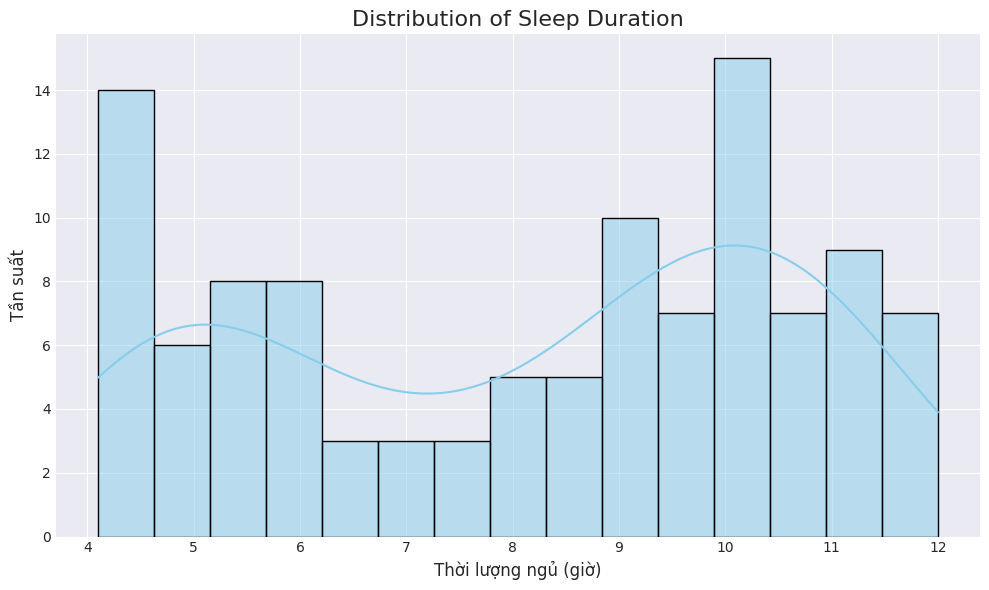

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data["Sleep Duration (hours)"], bins=15, kde=True, color='skyblue')
plt.title("Distribution of Sleep Duration", fontsize=16)
plt.xlabel("Thời lượng ngủ (giờ)", fontsize=12)
plt.ylabel("Tần suất", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

#### Nhận xét về Biểu đồ phân phối thời lượng ngủ (Distribution of Sleep Duration)

Biểu đồ cho thấy một phân phối hai đỉnh rõ rệt. Một đỉnh nằm trong khoảng 4.0 đến 5.0 giờ và một đỉnh khác, nổi bật hơn, nằm trong khoảng 9.5 đến 11.0 giờ. Điều này chỉ ra rằng có ít nhất hai nhóm khác biệt trong tập dữ liệu với các thói quen ngủ khác nhau (ví dụ: người ngủ ít và người ngủ nhiều). Phân phối này không theo phân phối chuẩn.

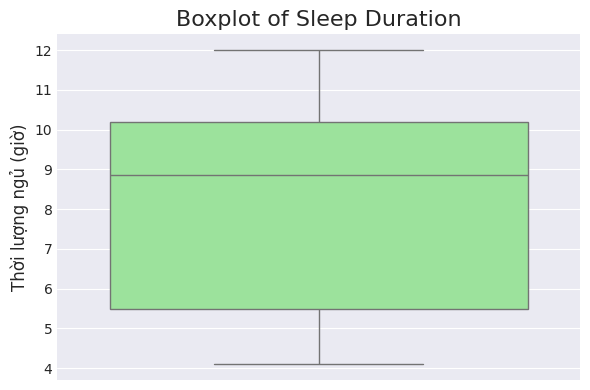

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=data["Sleep Duration (hours)"], color='lightgreen')
plt.title("Boxplot of Sleep Duration", fontsize=16)
plt.ylabel("Thời lượng ngủ (giờ)", fontsize=12)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

#### Nhận xét về Biểu đồ hộp của thời lượng ngủ (Boxplot of Sleep Duration)

Biểu đồ hộp của thời lượng ngủ minh họa sự phân tán của dữ liệu. Đường trung vị nằm quanh 8.85 giờ. Hộp, đại diện cho khoảng tứ phân vị (IQR), khá rộng, cho thấy sự biến động đáng kể về thời lượng ngủ. Không có giá trị ngoại lệ rõ ràng trong biểu đồ này. Các râu kéo dài đến giá trị nhỏ nhất (4.1 giờ) và lớn nhất (12.0 giờ), thể hiện toàn bộ phạm vi thời lượng ngủ mà không có giá trị cực đoan nào được phát hiện bởi tiêu chí ngoại lệ của biểu đồ hộp. Đường trung vị không nằm chính giữa hộp và các râu không đối xứng, phù hợp với phân phối hai đỉnh đã thấy trong biểu đồ tần suất.

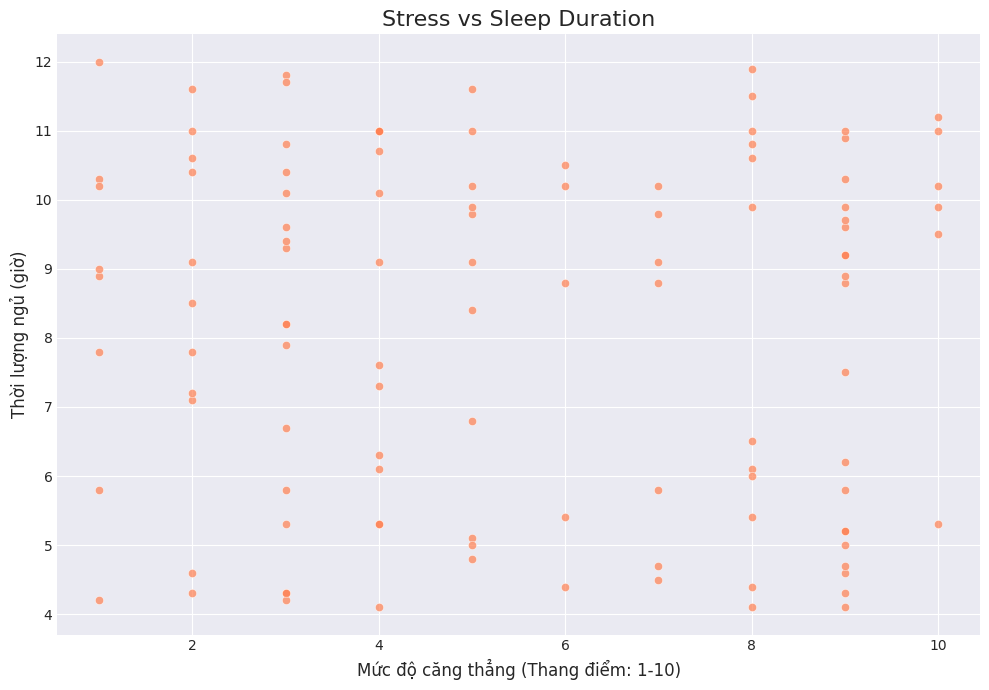

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=data["Stress Level (scale: 1-10)"],
    y=data["Sleep Duration (hours)"],
    color='coral',
    alpha=0.7
)
plt.xlabel("Mức độ căng thẳng (Thang điểm: 1-10)", fontsize=12)
plt.ylabel("Thời lượng ngủ (giờ)", fontsize=12)
plt.title("Stress vs Sleep Duration", fontsize=16)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

#### Nhận xét về Biểu đồ phân tán giữa mức độ căng thẳng và thời lượng ngủ (Stress vs Sleep Duration)

Biểu đồ phân tán giữa 'Mức độ căng thẳng (thang điểm 1-10)' và 'Thời lượng ngủ (giờ)' không cho thấy mối quan hệ tuyến tính rõ ràng hay xu hướng cụ thể nào. Các điểm dữ liệu dường như được phân tán ngẫu nhiên, cho thấy khi mức độ căng thẳng thay đổi, không có mô hình tăng hoặc giảm thời lượng ngủ một cách nhất quán. Quan sát trực quan này được củng cố mạnh mẽ bởi phân tích tương quan Pearson, với hệ số tương quan (r) xấp xỉ -0.044 và giá trị p (p) là 0.644. Vì giá trị p lớn hơn nhiều so với mức ý nghĩa thông thường (ví dụ: 0.05), chúng ta không bác bỏ giả thuyết không, kết luận rằng không có mối tương quan tuyến tính đáng kể về mặt thống kê giữa mức độ căng thẳng và thời lượng ngủ trong tập dữ liệu này.

**KẾT LUẬN**

Trong project này, bộ dữ liệu Sleep Health and Lifestyle đã được sử dụng để thực hiện phân tích kiểm định thống kê về thời lượng ngủ và các yếu tố liên quan. Trước khi phân tích, dữ liệu đã được kiểm tra về giá trị thiếu, dữ liệu trùng lặp và các đặc điểm thống kê cơ bản nhằm đảm bảo độ tin cậy của kết quả.

Kết quả thống kê mô tả và các biểu đồ trực quan cho thấy thời lượng ngủ của các đối tượng dao động trong khoảng từ khoảng 4 đến 12 giờ, dữ liệu tương đối ổn định và không xuất hiện các giá trị ngoại lệ đáng kể.

Đối với kiểm định Independent t-test, kết quả thu được là T-statistic = 0.453 và P-value = 0.651. Do giá trị P-value lớn hơn mức ý nghĩa 0.05, nên không bác bỏ giả thuyết H₀. Điều này cho thấy chưa có đủ bằng chứng thống kê để kết luận thời lượng ngủ trung bình giữa nam và nữ có sự khác biệt trong bộ dữ liệu được nghiên cứu.

Đối với kiểm định tương quan Pearson, kết quả cho thấy chưa có đủ bằng chứng thống kê để khẳng định tồn tại mối tương quan giữa mức độ căng thẳng (Stress Level) và thời lượng ngủ (Sleep Duration). Nói cách khác, trong phạm vi của bộ dữ liệu này, chưa thể kết luận rằng mức độ căng thẳng có ảnh hưởng đáng kể đến thời lượng ngủ.

Nhìn chung, project đã thực hiện đầy đủ các bước của một bài phân tích kiểm định thống kê, bao gồm: đọc và làm sạch dữ liệu, thống kê mô tả, trực quan hóa dữ liệu, xây dựng giả thuyết, thực hiện các phép kiểm định thống kê và diễn giải kết quả dựa trên p-value. Qua project này có thể thấy Python là một công cụ hiệu quả trong việc hỗ trợ phân tích dữ liệu và đưa ra các kết luận dựa trên cơ sở thống kê.